--- INSPECTING DATASET ---
Loading arrays (this might take a moment)...
Successfully loaded 3974 light curves.

Displaying KIC 8733898 (Index 746)


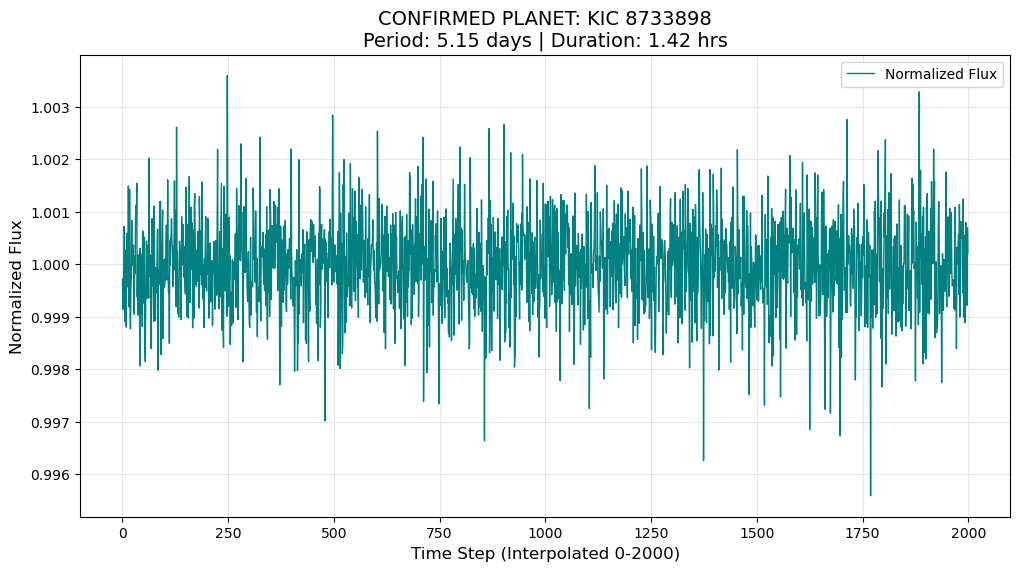

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configuration
DATA_DIR = "processed_data_new"
X_FILE = os.path.join(DATA_DIR, "X_data.npy")
KEY_FILE = os.path.join(DATA_DIR, "dataset_key.csv")

def inspect():
    print("--- INSPECTING DATASET ---")
    
    # 1. Check if files exist
    if not os.path.exists(X_FILE) or not os.path.exists(KEY_FILE):
        print(f"Error: Files not found in '{DATA_DIR}/'. Run the pipeline first.")
        return

    # 2. Load Data
    print("Loading arrays (this might take a moment)...")
    X = np.load(X_FILE)
    key = pd.read_csv(KEY_FILE)
    
    print(f"Successfully loaded {len(X)} light curves.")
    
    # 3. Filter for Confirmed Planets only
    planets = key[key['label'] == 'CONFIRMED']
    
    if planets.empty:
        print("No confirmed planets found in the key!")
        return

    # 4. Pick a random planet to plot
    # We use .sample(1) to get a random row, then get its index
    random_planet = planets.sample(1).iloc[0]
    idx = random_planet.name  # The index in the dataframe corresponds to the index in X
    
    # 5. Get Metadata
    kic_id = random_planet['kic']
    period = random_planet['period']
    duration = random_planet['duration']
    
    # 6. Plot
    plt.figure(figsize=(12, 6))
    
    # Plot the flux array for this specific index
    plt.plot(X[idx], color='teal', linewidth=1, label='Normalized Flux')
    
    # Formatting
    plt.title(f"CONFIRMED PLANET: KIC {kic_id}\nPeriod: {period:.2f} days | Duration: {duration:.2f} hrs", fontsize=14)
    plt.xlabel("Time Step (Interpolated 0-2000)", fontsize=12)
    plt.ylabel("Normalized Flux", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    print(f"\nDisplaying KIC {kic_id} (Index {idx})")
    plt.show()

if __name__ == "__main__":
    inspect()